# Auxiliary functions for MOPAC calculations

In this tutorial, we demonstrate some auxiliary functions that could be used with MOPAC calculations to get some properties relevant for NA-MD simulations, such as energies, orbitals, time-overlaps, etc.


## Table of contents
<a name="toc"></a>
1. [Importing needed libraries](#1)
2. [Reading a snapshot from the xyz trajectory file](#2)
3. [Creating input files for MOPAC calculations](#3)
4. [Running MOPAC calculations](#4)
5. [Reading molecular orbitals/energies and CI vectors](#5)
6. [Computing time-overlaps](#6)
7. [Reading molecular orbitals/energies and CI vectors. Using active space of MOs](#7)
8. [Possible sources of errors](#8)
9. [The remedy](#9)

   9.1. [Major flaw remedy - but low accuracy](#9.1)
   
   9.2. [Improving the accuracy](#9.2)
   
10. [The workflow](#10)

    10.1. [Standard approach - use all the orbitals](#10.1)
    
    10.2. [Using the reduced approach - use only a sub-space of orbitals](#10.2)
    
    10.3. [Let's compare the time-overlaps computed in the two ways](#10.3)


### A. Learning objectives

* To generate the input files for MOPAC calculations from the xyz trajectory file
* To extract the key infromation from the output file of MOPAC calculations (energies, MOs, CI vectors, etc.)
* To automate the calculations of the CI time-overlaps, adiabatic Hamiltonians, and adiabatic vibronic Hamiltonians using MOPAC


### B. Use cases

* INDO calculations with Libra 
* manually construct a Slater Determinant bais 
* processing the MOPAC calculations results
* computing CI wavefunction time-overlaps with MOPAC
* define Libra/MOPAC interface Hamiltonian
* computing single-particle (KS-DFT, HF, semiempirical) NACs
* computing many-body (TD-DFT, TD-DFTB, CI) NACs

### C. Functions

- `libra_py`
  - `workflows`
    - `nbra`
      - `mapping2`
        - [`ovlp_mat_arb`](#ovlp_mat_arb-1)
  - `packages`
    - `cp2k`
      - `methods`
        - [`read_trajectory_xyz_file`](#read_trajectory_xyz_file-1) | [`also here`](#read_trajectory_xyz_file-2)
    - `mopac`
      - `methods`
        - [`make_mopac_input`](#make_mopac_input-1)
        - [`run_mopac`](#run_mopac-1)
        - [`make_ref`](#make_ref-1)
        - [`make_alpha_excitation`](#make_alpha_excitation-1)
        - [`read_mopac_orbital_info`](#read_mopac_orbital_info-1)
        - [` mopac_compute_adi`](#mopac_compute_adi-1)
        

## 1. Importing needed libraries <a name="1"></a>
[Back to TOC](#toc)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from liblibra_core import *
import libra_py.data_conv as data_conv
import libra_py.packages.cp2k.methods as cp2k
import libra_py.packages.mopac.methods as mopac
import libra_py.workflows.nbra.mapping2 as mapping2
import libra_py.workflows.nbra.mapping3 as mapping3
import libra_py.units as units

import libra_py.citools.slatdet as sd
import libra_py.citools.csf as csf
import libra_py.citools.interfaces as interfaces

%matplotlib inline 

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 2. Reading  a snapshot from the xyz trajectory file<a name="2"></a>
[Back to TOC](#toc)

We read the first (zero-th) snapshot of the `TiO2-aligned.xyz` trajectory file

The function determines the names of the N atoms in the system and saves the x, y, and z coordinates to MATRIX(3N,1) format and converts the coordinates from Angstrom to Bohr

We can print out the atomic labels - 1 Ti and 2 O - this is a TiO2 cluster.

The execution of this function also creates the corresponding coordinate xyz file, named "coord-0.xyz". The numerical index corresponds to the index of the snapshot we are reading in
<a name="read_trajectory_xyz_file-1"></a>

In [2]:
labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", 0)

print(labels)
q.show_matrix()

['Ti', 'O', 'O']
-0.0000000  
-0.0037794520  
0.70297807  
-0.0000000  
2.6399472   
-1.0563568  
-0.0000000  
-2.6286089  
-1.0487979  



Read more:

In [3]:
help(cp2k.read_trajectory_xyz_file)

Help on function read_trajectory_xyz_file in module libra_py.packages.cp2k.methods:

read_trajectory_xyz_file(file_name: str, step: int)
    This function reads the trajectory of a molecular dynamics .xyz file and
    extract the 'step' th step then writes it to coord-step.xyz file. This function
    is used in single point calculations for calculations of the NACs where one has
    previously obtained the trajectory via any molecular dynamics packages.
    
    Args:
    
        file_name (string): The trajectory .xyz file name.
            step (integer): The desired time to extract its .xyz
                            coordinates which starts from zero.
    
    Returns:
    
        (list, MATRIX(ndof, 1)): labels of all atoms, and their coordinates, ndof = 3 * natoms



## 3. Creating input files for MOPAC calculations<a name="3"></a>
[Back to TOC](#toc)

We are now ready to use this information to create an input file for MOPAC calculations using `make_mopac_input`
<a name="make_mopac_input-1"></a>

In [4]:
help(mopac.make_mopac_input)

Help on function make_mopac_input in module libra_py.packages.mopac.methods:

make_mopac_input(mopac_input_filename, mopac_run_params, labels, coords)
    This function creates an input file for MOPAC package using the
    parameters passed in the `mopac_input_params` dictionary
    
    Args:
        * mopac_input_filename ( string ): the name of the input file to create
    
        * mopac_run_params ( string ): the string containing the specification for the MOPAC run.
        E.g. one can use: "INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=2"
    
        * labels (list of stings): element symbols for atoms in the system (N items), e.g.
         ["C", "H", "H", "H", "H"] for methane
    
        * coords ( MATRIX(3N, 1) ): Cartesian coordinates of all atoms ordered in triples x, y, z [ units: Bohr ]
    
    Returns:
        None :  just creates the files



In particular, we are going to create an "input.mop" file in whihch we'll request CASSCF(6,3) calculations on the read benzene geometry. We also request to print the MOs and CI vectors:

In [5]:
mopac_input_filename = "input.mop"
mopac_run_params = "INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=2"
mopac.make_mopac_input(mopac_input_filename, mopac_run_params, labels, q)

## 4. Running MOPAC calculations<a name="4"></a>
[Back to TOC](#toc)

To prepare the working folders, input files (from the xyz trajectory files) and to run the MOPAC calculations, we can use the `run_mopac` function:
<a name="run_mopac-1"></a>

In [6]:
help(mopac.run_mopac)

Help on function run_mopac in module libra_py.packages.mopac.methods:

run_mopac(coords, params_)
    This function executes the MOPAC quantum chemistry calculations
    
    Args:
        coords ( MATRIX(ndof, 1) ): coordinates of the particle [ units: Bohr ]
        params ( dictionary ): model parameters
    
            * **params_["labels"]** ( list of strings ): the labels of atomic symbolc - for all atoms,
                and in a order that is consistent with the coordinates (in triples) stored in `q`.
                The number of this labels is `natoms`, such that `ndof` = 3 * `natoms`. [ Required ]
            * **params_["mopac_exe"]** ( string ):  the full path to `the mopac` executable [ defaut: "mopac" ]
            * **params_["mopac_run_params"]** ( string ): the control string to define the MOPAC job
                [default: "INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=2"]
            * **params_["mopac_working_directory"]** ( string ) [ defa

As you can see, this function takes quite a while inputs, although some of them are already familiar to use. Indeed, this is what the functions called by this function will need to know

Now, we are going to read 5 snapshots from the trajectory files and create the corresponding input files and execute the corresponding MOPAC outputs.

Parameters:

   * `labels` - those we had already created
   * `mopac_exe` = "/home/alexvakimov/SOFTWARE/mopac/_build/mopac" - this is where the exe is located at the time of preparation of this tutorial
   * `mopac_run_params` - we don't specify anything - use the default string
   * `mopac_working_directory` - we don't specify anything - use the default value of "mopac_wd". This is the folder that will be created upon the first run. If the folder already exists - the present one will be used.
   * `mopac_jobid` - we distinguis the inputs and outputs for all timesteps; this is needed in case we run many jobs in parallel or the calculations are fast so may interfere with reading-writing the files.
   * `mopac_output_prefix` - this is where some job-related output will be redirected; note that MOPAC will create the output files with the prefixes related to the input files

<a name="read_trajectory_xyz_file-2"></a>

In [7]:
params_ = { "labels": labels, "mopac_exe":"/home/alexvakimov/SOFTWARE/mopac/_build/mopac" }

for i in range(5):
    _, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", i)
    params_.update( {"mopac_jobid":F"job{i}"} )
    mopac.run_mopac(q, params_)

As a result, this step should create the folder with the following content:

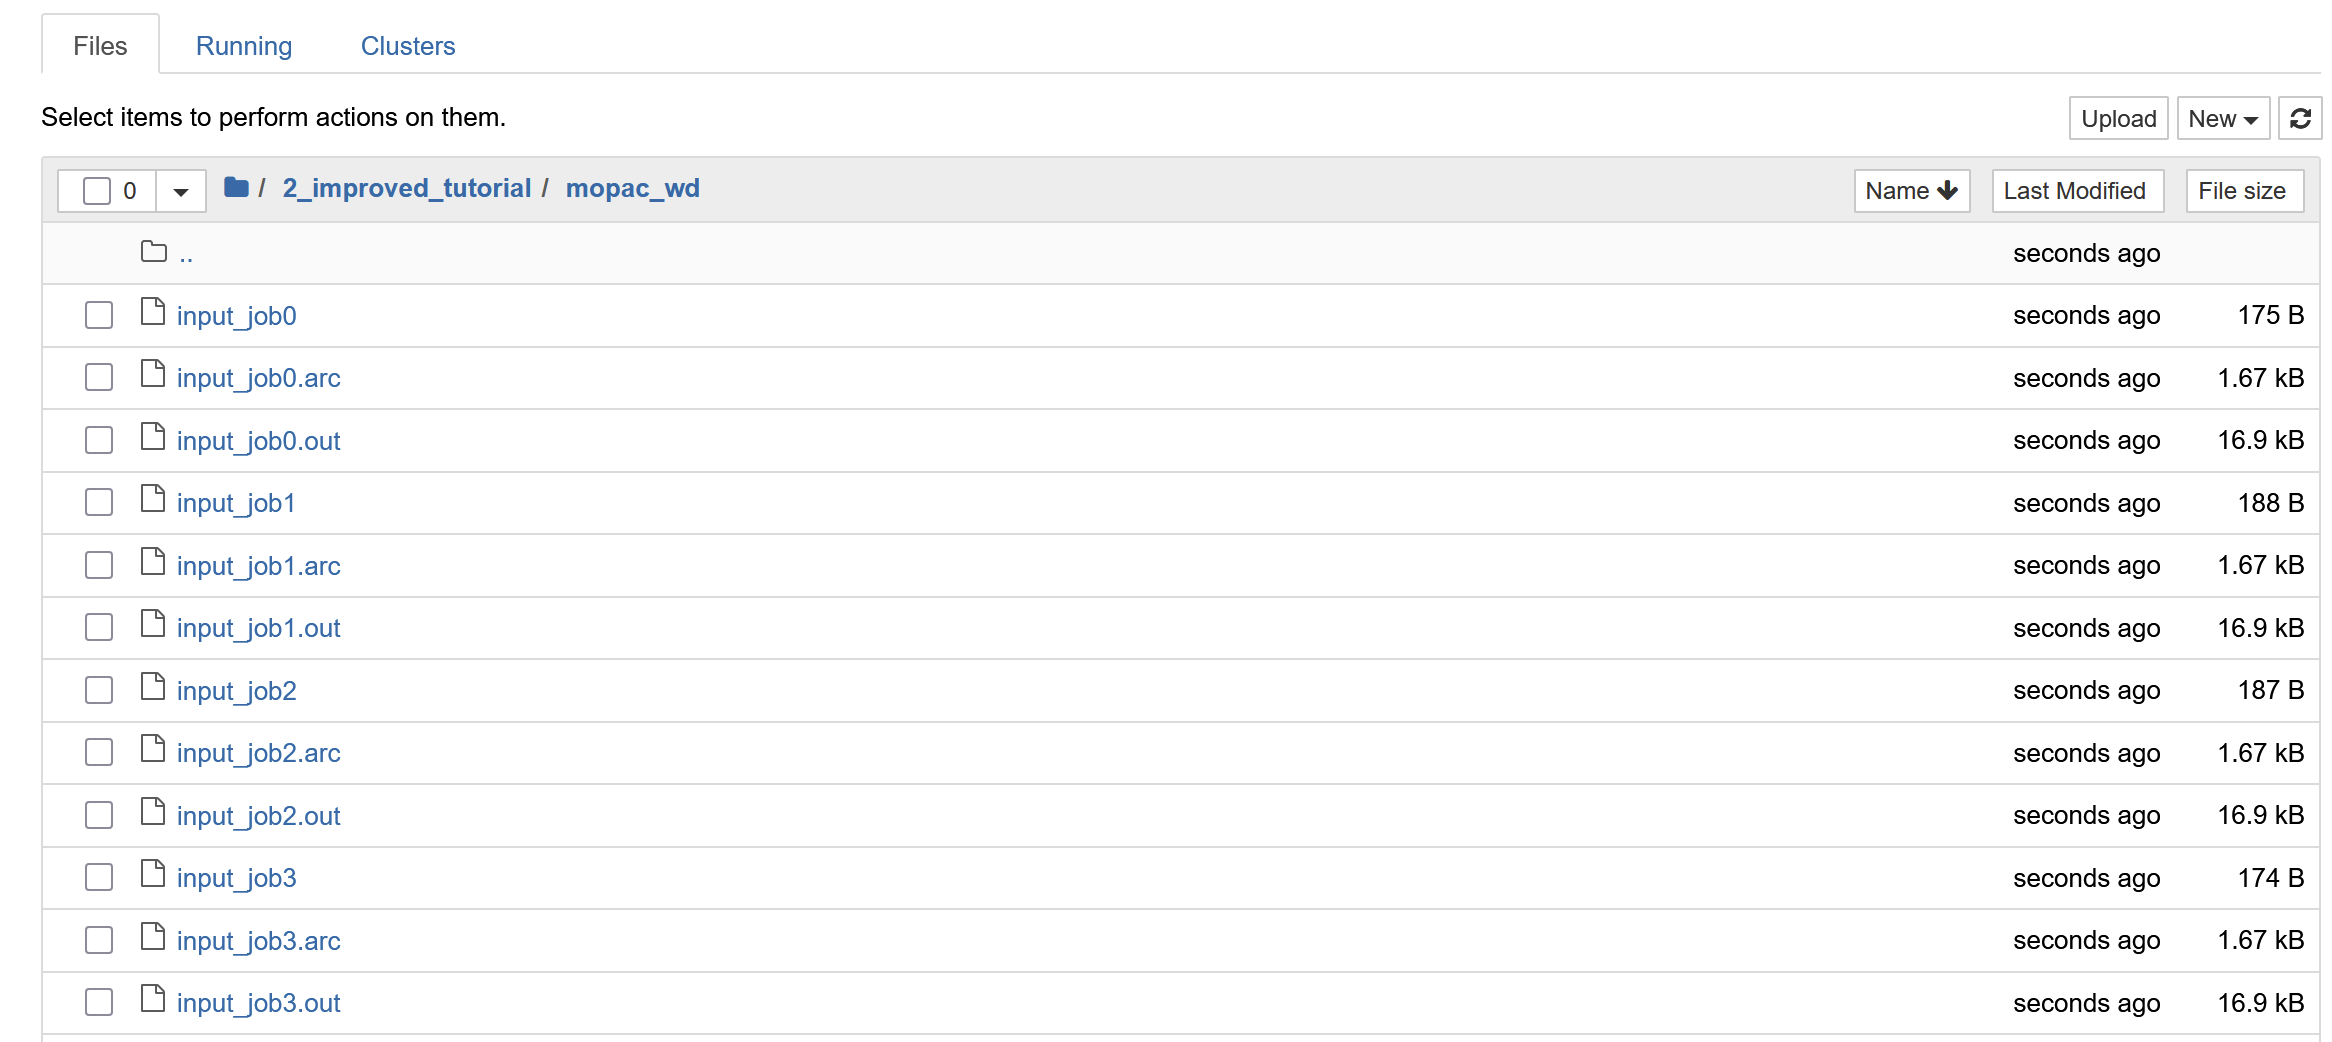

## 5. Reading molecular orbitals/energies and CI vectors<a name="4"></a>
[Back to TOC](#toc)

Now we are ready to parse the output files generated. This is done using `read_mopac_orbital_info` function:
<a name="read_mopac_orbital_info-1"></a>

In [8]:
help(mopac.read_mopac_orbital_info)

Help on function read_mopac_orbital_info in module libra_py.packages.mopac.methods:

read_mopac_orbital_info(params_)
    This function reads the MOs, configurations, and CI from the output files
    
    Args:
    
        params_ ( dict ): the dictionary containing key parameters
    
            * **params_["filename"]** ( string ) : the name of the file to read
            * **params_["orbital_space"]** (list of ints): the orbital numbers to be included, the indexing starts with 1, not 0 [default: None]
            * **params_["nstates"]** ( int ): the number of CI states + ground state to use, `nstates = 2` means 1 ground and 1 excited states
    
    Returns:
        (Es, MOs, E_CI, CI, configs):
    
            * Es - MATRIX(nact, nact): the matrix of the MO energies for active MOs
            * MOs - MATRIX(nao, nact): the matrix of MO-LCAO coefficients for active MOs
            * E_CI - MATRIX(nci, nci): the matrix of CI energies
            * CI - MATRIX(nconf, nci): the ma

Let's first see what this function gives us:

If we don't specify any active orbital space - all the available orbitals will be listed in the reference determinant - the config that comes up first. The length of the configurations will correspond to how many electrons we have to distribute across these orbitals.

In [9]:
params = { "filename": "mopac_wd/input_job0.out", }
E0, MO0, E_CI0, CI0, configs0, configs_raw0, actual_orbital_space = mopac.read_mopac_orbital_info(params)

The raw configurations will be given in absolute numbers

In [10]:
configs_raw0

[[1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 9, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 10, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 11, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 9, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 9, -6, 7, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 11, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 10, -6, 7, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 10, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 11, -6, 7, -7, 8, -8]]

Just configs will use the indices within the actual orbital spaces. 
In this example, we use the full space, so the re-indexed configurations will be the same as the raw:

In [11]:
configs_raw0

[[1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 9, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 10, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 11, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 9, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 9, -6, 7, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 11, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 10, -6, 7, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 10, -7, 8, -8],
 [1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 11, -6, 7, -7, 8, -8]]

And here is how the actual orbital space looks like - we include all the MOs that are available in the system

In [12]:
actual_orbital_space

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Let's plot the MOs for that - this will be a matrix with 17 columns

In [13]:
MO0.show_matrix()

0.25158000  0.10083000  0.029380000  0.0010000000  -0.0000000  -0.076530000  0.0000000   0.00071000000  0.85102000  -0.0000000  0.080370000  0.0000000   -0.00027000000  0.0000000   -0.034400000  -0.43352000  -0.0024900000  
-0.0000000  -0.0000000  -0.0000000  -0.0000000  0.023770000  -0.0000000  0.24847000  0.0000000   -0.0000000  0.48611000  0.0000000   0.030920000  -0.0000000  0.83692000  0.0000000   -0.0000000  -0.0000000  
-0.11361000  0.28381000  -0.0017100000  0.012750000  -0.0000000  -0.0040500000  -0.0000000  0.18616000  -0.00028000000  -0.0000000  -0.0048700000  -0.0000000  0.62796000  0.0000000   0.0049800000  -0.0051800000  0.69087000  
-0.18823000  -0.075380000  0.12476000  -0.0034600000  0.0000000   0.13512000  0.0000000   0.0030700000  0.32033000  -0.0000000  0.46775000  -0.0000000  0.0099400000  -0.0000000  -0.47932000  0.61138000  0.0027800000  
-0.010520000  -0.0044500000  -0.36910000  0.010450000  -0.0000000  -0.24422000  -0.0000000  -0.0061500000  -0.041400000  -0.00

### How the configurations are constructed

The ground-state configuration for 16 electrons can be generated using `make_ref` function, like this:
<a name="make_ref-1"></a>

In [14]:
GS = mopac.make_ref(16)

print(GS)

[1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 8, -8]


In [15]:
help(mopac.make_ref)

Help on function make_ref in module libra_py.packages.mopac.methods:

make_ref(nelec, active_space=None)
    Makes the reference determinant based on the number of electrons
    
    Args:
        nelec (int) : the total number of electrons in the system
        active_space (list of ints): the indices of allowed orbitals, starting from 1 [default: None]
    
    Returns:
        list of ints: representation of the reference (ground-state) determinant
    
        E.g. [1, -1, 2, -2] is the determinant of 4 electrons with 2 lowest orbitals doubly-filled
        Here, the indexing starts with 1, and negative values correspond to the beta-spin electron
        while positive values - to the alpha-spin electron.
    
        If the active_space is [2], then the above reference determinant will become just [2, -2]



Other configurations are produced by the excitation of the ground state configuration using `make_alpha_excitation` function. For instance, the first excited configuration for the system is obtained by the $8 \to 9$ excitation:
<a name="make_alpha_excitation-1"></a>

In [16]:
S1 = mopac.make_alpha_excitation(GS, [8, 9])
print(S1)

[1, -1, 2, -2, 3, -3, 4, -4, 5, -5, 6, -6, 7, -7, 9, -8]


In [17]:
help(mopac.make_alpha_excitation)

Help on function make_alpha_excitation in module libra_py.packages.mopac.methods:

make_alpha_excitation(ref_determinant, config)
    This function creates an excitation of the alpha electron in the reference determinant
    exciting the electron from and to orbitals determined by the `config` argument
    
    Args:
    
        ref_determinant (list of ints): representation of the reference determinants
    
        config (list of 2 ints): [src, targt]  - source and target orbitals for single excitation, the
            indexing starts from 1, not from 0.
    
    Returns:
        list of ints: the representation of the excited configuration
    
    Example:
        make_alpha_excitation([1, -1, 2, -2], [2, 3])  corresponds to 2->3 excitation and should return
    
        [1, -1, 3, -2]



### Reduced orbital space
In practical calculations, especially for large systems, we don't need all the orbitals - only some frontier ones.

So, we can call the `read_mopac_orbital_info` function with the `orbital_space` parameter that defines a reduced subspace of MOs to use

In [18]:
params = { "filename": "mopac_wd/input_job0.out", 
           "orbital_space": [6,7,8, 9,10,11] }
E0, MO0, E_CI0, CI0, configs0, configs_raw0, actual_orbital_space = mopac.read_mopac_orbital_info(params)

Let's look at the configs - they are now lists of 6 (spin-)-orbitals with all the electrons that occupy this space - 3 pairs (6 electrons). This is consistent with the CAS(6,3) we will be using later

In [19]:
configs_raw0

[[6, -6, 7, -7, 8, -8],
 [6, -6, 7, -7, 9, -8],
 [6, -6, 7, -7, 10, -8],
 [6, -6, 7, -7, 11, -8],
 [6, -6, 9, -7, 8, -8],
 [9, -6, 7, -7, 8, -8],
 [6, -6, 11, -7, 8, -8],
 [10, -6, 7, -7, 8, -8],
 [6, -6, 10, -7, 8, -8],
 [11, -6, 7, -7, 8, -8]]

The configurations reindexed to the reduced orbital space are:

In [20]:
configs0

[[1, -1, 2, -2, 3, -3],
 [1, -1, 2, -2, 4, -3],
 [1, -1, 2, -2, 5, -3],
 [1, -1, 2, -2, 6, -3],
 [1, -1, 4, -2, 3, -3],
 [4, -1, 2, -2, 3, -3],
 [1, -1, 6, -2, 3, -3],
 [5, -1, 2, -2, 3, -3],
 [1, -1, 5, -2, 3, -3],
 [6, -1, 2, -2, 3, -3]]

The actual orbital space is:

In [21]:
actual_orbital_space

[6, 7, 8, 9, 10, 11]

So, the corresponding MOs will have only 6 columns containing initial orbitals 6, 7, 8, ... 11

In [22]:
MO0.show_matrix()

-0.076530000  0.0000000   0.00071000000  0.85102000  -0.0000000  0.080370000  
-0.0000000  0.24847000  0.0000000   -0.0000000  0.48611000  0.0000000   
-0.0040500000  -0.0000000  0.18616000  -0.00028000000  -0.0000000  -0.0048700000  
0.13512000  0.0000000   0.0030700000  0.32033000  -0.0000000  0.46775000  
-0.24422000  -0.0000000  -0.0061500000  -0.041400000  -0.0000000  0.71658000  
0.24481000  0.0000000   -0.0014800000  0.38677000  0.0000000   -0.44448000  
0.0000000   0.050550000  -0.0000000  -0.0000000  -0.0085800000  -0.0000000  
0.0000000   -0.39661000  -0.0000000  0.0000000   0.83974000  0.0000000   
0.018160000  0.0000000   0.086440000  6.0000000e-05  0.0000000   -0.0062700000  
0.13112000  0.0000000   -0.055740000  -0.083170000  -0.0000000  0.018560000  
0.0000000   0.67992000  0.0000000   -0.0000000  0.17404000  0.0000000   
0.65881000  0.0000000   0.17394000  -0.044360000  -0.0000000  0.17808000  
-0.072360000  -0.0000000  0.67968000  0.043930000  -0.0000000  0.022260000  

Now, let's read similar information for another geometry:

In [23]:
params = { "filename": "mopac_wd/input_job1.out", 
           "orbital_space": [6,7,8, 9,10,11] }
E1, MO1, E_CI1, CI1, configs1, configs_raw1, actual_orbital_space = mopac.read_mopac_orbital_info(params)

For this one, let's print different properties that we haven't explored yet:

MO energies (in eV):

In [24]:
E1.show_matrix()

-12.164380  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   -11.966390  0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   -10.812930  0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.0000000   -1.6022800  0.0000000   0.0000000   
0.0000000   0.0000000   0.0000000   0.0000000   -0.49424000  0.0000000   
0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   -0.42137000  



Energies of CI states:

In [25]:
E_CI1.show_matrix()

0.0000000   0.0000000   
0.0000000   0.16201904  



CI coefficients giving the amplitudes of the corresponding spin-adapted configurations corresoinding to the determined excited Slater determinants (configurations):

In [26]:
CI1.show_matrix()

1.0000000   0.0000000   
0.0000000   0.97780925  
0.0000000   -0.0000000  
0.0000000   -0.20948825  
0.0000000   -0.0000000  
0.0000000   0.00047703000  
0.0000000   0.0000000   
0.0000000   0.0000000   
0.0000000   -0.0016308600  
0.0000000   0.00092692000  



## 6. Creating spin-adapted configurations (detailed)<a name="6"></a>
[Back to TOC](#toc)

Now, have some basis of excited Slater determinants. However, this is not a complete set of such determinants needed to construct all spin-adapted condfigurations (also known as configuration state functions, CSFs). 

For the considered above CAS(6,3), with the active orbitals being 6,7,8,9,10, and 11, we can construct all the CSFs using the `citools` module:

In [27]:
dets = list(sd.generate_determinants_with_parity([6,7,8,9,10,11], 6))

print(dets)
print(len(dets))

[((6, -6, 7, -7, 8, -8), 1), ((6, -6, 7, -7, 8, 9), 1), ((6, -6, 7, -7, 8, -9), 1), ((6, -6, 7, -7, 8, 10), 1), ((6, -6, 7, -7, 8, -10), 1), ((6, -6, 7, -7, 8, 11), 1), ((6, -6, 7, -7, 8, -11), 1), ((6, -6, 7, -7, -8, 9), 1), ((6, -6, 7, -7, -8, -9), 1), ((6, -6, 7, -7, -8, 10), 1), ((6, -6, 7, -7, -8, -10), 1), ((6, -6, 7, -7, -8, 11), 1), ((6, -6, 7, -7, -8, -11), 1), ((6, -6, 7, -7, 9, -9), 1), ((6, -6, 7, -7, 9, 10), 1), ((6, -6, 7, -7, 9, -10), 1), ((6, -6, 7, -7, 9, 11), 1), ((6, -6, 7, -7, 9, -11), 1), ((6, -6, 7, -7, -9, 10), 1), ((6, -6, 7, -7, -9, -10), 1), ((6, -6, 7, -7, -9, 11), 1), ((6, -6, 7, -7, -9, -11), 1), ((6, -6, 7, -7, 10, -10), 1), ((6, -6, 7, -7, 10, 11), 1), ((6, -6, 7, -7, 10, -11), 1), ((6, -6, 7, -7, -10, 11), 1), ((6, -6, 7, -7, -10, -11), 1), ((6, -6, 7, -7, 11, -11), 1), ((6, -6, 7, 8, -8, 9), 1), ((6, -6, 7, 8, -8, -9), 1), ((6, -6, 7, 8, -8, 10), 1), ((6, -6, 7, 8, -8, -10), 1), ((6, -6, 7, 8, -8, 11), 1), ((6, -6, 7, 8, -8, -11), 1), ((6, -6, 7, 8, 9, 

As you can tell, this list of possible determinants is too large and not all of the configurations are needed:

* we don't need the configurations with the excitations that are not included in the `configs_raw` extracted earlier from our INDO/CI calculations - probably, those have very small amplitudes;

* we also don't need the determinants that are not consistent with our multiplicity - e.g. we are only interested in singlet CSFs, we don't need determinants with  unpaired electrons.

So, we need to reduce this generated basis by some filtering. This can be done with the help of 

`interfaces.build_minimal_csf_basis` function:

In [28]:
min_basis, (all_confs, all_phases) = interfaces.build_minimal_csf_basis(configs_raw1, active_space=[6,7,8,9,10,11], nelec=6, max_unpaired=0)

print(min_basis)
print(all_confs)
print(all_phases)

[((6, -6, 7, -7, 8, -8), 1), ((6, -6, 7, -7, 8, -9), 1), ((6, -6, 7, -7, -8, 9), 1), ((6, -6, 7, -7, 8, -10), 1), ((6, -6, 7, -7, -8, 10), 1), ((6, -6, 7, -7, 8, -11), 1), ((6, -6, 7, -7, -8, 11), 1), ((6, -6, 7, 8, -8, -9), 1), ((6, -6, -7, 8, -8, 9), 1), ((6, 7, -7, 8, -8, -9), 1), ((-6, 7, -7, 8, -8, 9), 1), ((6, -6, 7, 8, -8, -11), 1), ((6, -6, -7, 8, -8, 11), 1), ((6, 7, -7, 8, -8, -10), 1), ((-6, 7, -7, 8, -8, 10), 1), ((6, -6, 7, 8, -8, -10), 1), ((6, -6, -7, 8, -8, 10), 1), ((6, 7, -7, 8, -8, -11), 1), ((-6, 7, -7, 8, -8, 11), 1)]
((6, -6, 7, -7, 8, -8), (6, -6, 7, -7, 8, -9), (6, -6, 7, -7, -8, 9), (6, -6, 7, -7, 8, -10), (6, -6, 7, -7, -8, 10), (6, -6, 7, -7, 8, -11), (6, -6, 7, -7, -8, 11), (6, -6, 7, 8, -8, -9), (6, -6, -7, 8, -8, 9), (6, 7, -7, 8, -8, -9), (-6, 7, -7, 8, -8, 9), (6, -6, 7, 8, -8, -11), (6, -6, -7, 8, -8, 11), (6, 7, -7, 8, -8, -10), (-6, 7, -7, 8, -8, 10), (6, -6, 7, 8, -8, -10), (6, -6, -7, 8, -8, 10), (6, 7, -7, 8, -8, -11), (-6, 7, -7, 8, -8, 11))
(1, 1

In [29]:
help(interfaces.build_minimal_csf_basis)

Help on function build_minimal_csf_basis in module libra_py.citools.interfaces:

build_minimal_csf_basis(configs: List[Tuple[int, ...]], active_space: List[int], nelec: int, max_unpaired: int) -> Tuple[List[Tuple[Any, ...]], List[Tuple[Any, ...]]]
    Construct a minimal CSF (Configuration State Function) basis
    from raw MOPAC/Libra configurations.
    
    Parameters
    ----------
    configs : list[tuple[int]]
        Configurations extracted from Libra or MOPAC output (raw orbital numbers).
    active_space : list[int]
        List of active orbital numbers defining the active space.
    nelec : int
        Total number of electrons.
    max_unpaired : int
        Twice the target spin projection (2*Ms).
        For example, 0 corresponds to singlet-only configurations.
    
    Returns
    -------
    min_basis : list[tuple]
        List of matching determinants (CSFs) as (configuration, phase) tuples.
    transposed_basis : list[tuple]
        Transposed representation, i.e. `

However, the `min_basis` that is generated by this function uses an absolute indexing of orbitals. This is not consistent with the reduced orbital space MO matrices we extracted earlier (e.g. since thier count may end with index of 5 already, but the configurations have indices 6, 7, ...). This would be an inconvenience when computing overlap matrices later. To alleviate this problem, we can use the `interfaces.map_to_active_indices` function with the appropriate selection of orbital space:

In [30]:
# Here, we use the consistent `actual_orbital_space` as the argument for active_space 

mapped = interfaces.map_to_active_indices(all_confs, active_space=[6,7,8,9,10,11])

for i in range( len(mapped) ):
    print(F"Configuration {i}: {all_confs[i]}  -> {mapped[i]}")    

Configuration 0: (6, -6, 7, -7, 8, -8)  -> (1, -1, 2, -2, 3, -3)
Configuration 1: (6, -6, 7, -7, 8, -9)  -> (1, -1, 2, -2, 3, -4)
Configuration 2: (6, -6, 7, -7, -8, 9)  -> (1, -1, 2, -2, -3, 4)
Configuration 3: (6, -6, 7, -7, 8, -10)  -> (1, -1, 2, -2, 3, -5)
Configuration 4: (6, -6, 7, -7, -8, 10)  -> (1, -1, 2, -2, -3, 5)
Configuration 5: (6, -6, 7, -7, 8, -11)  -> (1, -1, 2, -2, 3, -6)
Configuration 6: (6, -6, 7, -7, -8, 11)  -> (1, -1, 2, -2, -3, 6)
Configuration 7: (6, -6, 7, 8, -8, -9)  -> (1, -1, 2, 3, -3, -4)
Configuration 8: (6, -6, -7, 8, -8, 9)  -> (1, -1, -2, 3, -3, 4)
Configuration 9: (6, 7, -7, 8, -8, -9)  -> (1, 2, -2, 3, -3, -4)
Configuration 10: (-6, 7, -7, 8, -8, 9)  -> (-1, 2, -2, 3, -3, 4)
Configuration 11: (6, -6, 7, 8, -8, -11)  -> (1, -1, 2, 3, -3, -6)
Configuration 12: (6, -6, -7, 8, -8, 11)  -> (1, -1, -2, 3, -3, 6)
Configuration 13: (6, 7, -7, 8, -8, -10)  -> (1, 2, -2, 3, -3, -5)
Configuration 14: (-6, 7, -7, 8, -8, 10)  -> (-1, 2, -2, 3, -3, 5)
Configuratio

In [31]:
help(interfaces.map_to_active_indices)

Help on function map_to_active_indices in module libra_py.citools.interfaces:

map_to_active_indices(configs: List[Tuple[int, ...]], active_space: List[int]) -> List[Tuple[int, ...]]
    Map orbital configurations from absolute orbital numbers to
    indices relative to the given active space (starting from 1).
    
    The signs of the orbitals (±) are preserved, meaning that
    positive/negative indices still indicate α/β spins.
    
    Parameters
    ----------
    configs : list[tuple[int, ...]]
        List of configurations, where each configuration is a tuple
        of signed orbital numbers (e.g., (6, -6, 7, -7, 9, -8)).
        Positive values correspond to α-spin, and negative to β-spin.
    active_space : list[int]
        The ordered list of orbital numbers defining the active space.
        Example: [6, 7, 8, 9, 10, 11]
    
    Returns
    -------
    list[tuple[int, ...]]
        List of configurations with each orbital mapped to its
        corresponding index in the

Finally that we have a minimal basis of needed configurations that are also related to configurations shown in the MOPAC output, we need to compute the matrix of transformation between configurations and CSFs. This is done with the following funciton: `interfaces.conf2csf_matrix`

In [32]:
T = interfaces.conf2csf_matrix(min_basis, all_confs, all_phases, S = 0, Ms = 0)

In [33]:
T.real().show_matrix()

1.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   -0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   -0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.0000000   0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.0000000   -0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.0000000   0.0000000   0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.000

In this function, we request to consider only CSFs that are needed for particular kind of spin multiplet states (singlets), given out minimalistic SD basis.

In [34]:
help(interfaces.conf2csf_matrix)

Help on function conf2csf_matrix in module libra_py.citools.interfaces:

conf2csf_matrix(min_basis: List[Tuple[Tuple[int, ...], int]], all_confs: List[Tuple[int, ...]], all_phases: List[int], S: int = 0, Ms: int = 0) -> 'CMATRIX'
    Build the configuration-to-CSF (Configuration State Function) transformation matrix.
    
    This matrix `T` transforms the determinant (Slater determinant) basis
    into the spin-adapted CSF basis for a given total spin `S` and projection `Ms`.
    
    Parameters
    ----------
    min_basis : list[tuple[tuple[int], int]]
        Minimal determinant basis (e.g., output from `build_minimal_csf_basis`),
        where each element is a tuple `(configuration, phase)`.
    all_confs : list[tuple[int]]
        List of configurations (determinants) corresponding to rows of the matrix.
        Typically obtained as `all_confs, all_phases = zip(*min_basis)`.
    all_phases : list[int]
        Parity or phase factors corresponding to each determinant.
    S : in

## 7. Creating spin-adapted configurations (easier)<a name="6"></a>
[Back to TOC](#toc)

Now lets look at a higher-level function that takes care of creation of CSFs. In the end, we only need two things for the further calculations:

- the basis of configurations with the indexing within the selected orbital space
- the SD-to-CSFs transformation coefficients (T)

These calculations can be streamlined like this:

In [35]:
configs_raw1

[[6, -6, 7, -7, 8, -8],
 [6, -6, 7, -7, 9, -8],
 [6, -6, 7, -7, 10, -8],
 [6, -6, 7, -7, 11, -8],
 [6, -6, 9, -7, 8, -8],
 [9, -6, 7, -7, 8, -8],
 [6, -6, 11, -7, 8, -8],
 [10, -6, 7, -7, 8, -8],
 [6, -6, 10, -7, 8, -8],
 [11, -6, 7, -7, 8, -8]]

In [36]:
mapped_basis1, T1 = interfaces.configs_and_T_matrix(configs_raw1, 
                                                    active_space=[6,7,8,9,10,11], 
                                                    orbital_space=[6,7,8,9,10,11],
                                                    nelec=6, S=0, Ms=0)

In [37]:
mapped_basis1

[(1, -1, 2, -2, 3, -3),
 (1, -1, 2, -2, 3, -4),
 (1, -1, 2, -2, -3, 4),
 (1, -1, 2, -2, 3, -5),
 (1, -1, 2, -2, -3, 5),
 (1, -1, 2, -2, 3, -6),
 (1, -1, 2, -2, -3, 6),
 (1, -1, 2, 3, -3, -4),
 (1, -1, -2, 3, -3, 4),
 (1, 2, -2, 3, -3, -4),
 (-1, 2, -2, 3, -3, 4),
 (1, -1, 2, 3, -3, -6),
 (1, -1, -2, 3, -3, 6),
 (1, 2, -2, 3, -3, -5),
 (-1, 2, -2, 3, -3, 5),
 (1, -1, 2, 3, -3, -5),
 (1, -1, -2, 3, -3, 5),
 (1, 2, -2, 3, -3, -6),
 (-1, 2, -2, 3, -3, 6)]

In [38]:
T1.real().show_matrix()

1.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   -0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   -0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.0000000   0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.0000000   -0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.0000000   0.0000000   0.70710678  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.000

In [39]:
help(interfaces.configs_and_T_matrix)

Help on function configs_and_T_matrix in module libra_py.citools.interfaces:

configs_and_T_matrix(configs0_raw: List[Tuple[int, ...]], active_space: List[int], orbital_space: List[int], nelec: int, S: int, Ms: int) -> Tuple[List[Tuple[int, ...]], ForwardRef('CMATRIX')]
    Generate the minimal active-space configurations mapped to a given orbital space
    and the configuration-to-CSF transformation matrix for a CAS with given spin.
    
    Parameters
    ----------
    configs0_raw : list[tuple[int]]
        List of raw configurations from Libra/MOPAC (signed orbital indices).
    active_space : list[int]
        Orbitals defining the active space used to generate the minimal determinant basis.
    orbital_space : list[int]
        Orbital indices used for mapping configurations (output will be relative to this space).
    nelec : int
        Number of active electrons.
    S : int
        Total spin quantum number.
    Ms : int
        Spin projection quantum number.
    
    Retur

For completeness, let's compute the T-matrix and basis for the initial configuration:

In [40]:
mapped_basis0, T0 = interfaces.configs_and_T_matrix(configs_raw0, 
                                                    active_space=[6,7,8,9,10,11], 
                                                    orbital_space=[6,7,8,9,10,11],
                                                    nelec=6, S=0, Ms=0)

## 8.Computing time-overlaps<a name="6"></a>
[Back to TOC](#toc)

Finally, we can use the information read from the two timesteps to compute some properties.

First - the number of MOs:

In [41]:
nmo = MO0.num_of_cols
print(nmo)

6


Second - the time-overlap in the MO basis. 

Since we are using INDO approximation, the time-overlaps of the AOs are assumed to be the identity matrix:

In [42]:
mo_st = MO0.T() * MO1  # time-overlap in MO basis
mo_st.show_matrix()

0.99984098  0.0000000   0.0045088177  -6.9590000e-06  0.0000000   -0.00072644650  
0.0000000   0.99915714  0.0000000   0.0000000   -0.00074816560  0.0000000   
-0.0045265165  0.0000000   0.99996326  -0.00070388090  0.0000000   -0.00041740100  
-2.7187000e-06  0.0000000   0.00070178490  1.0000010   0.0000000   0.00076656940  
0.0000000   0.00076019340  0.0000000   0.0000000   0.99998659  0.0000000   
0.00073012520  0.0000000   0.00041773420  -0.00076920130  0.0000000   0.99999030  



Next, using the definitions of the SD configurations and the computed MO time-overlaps, we can now compute the time-overlaps of the SD functions. This is based on the function `sd.slater_overlap_matrix` which uses the Lowdin formula for computing overlaps of the determinants.
<a name="ovlp_mat_arb-1"></a>

In [43]:
# First, let's convert the MO overlaps to numpy format
mo_st_np = data_conv.MATRIX2nparray(mo_st).real  # MATRIX -> real np array
print(mo_st_np)

[[ 9.99840981e-01  0.00000000e+00  4.50881770e-03 -6.95900000e-06
   0.00000000e+00 -7.26446500e-04]
 [ 0.00000000e+00  9.99157141e-01  0.00000000e+00  0.00000000e+00
  -7.48165600e-04  0.00000000e+00]
 [-4.52651650e-03  0.00000000e+00  9.99963257e-01 -7.03880900e-04
   0.00000000e+00 -4.17401000e-04]
 [-2.71870000e-06  0.00000000e+00  7.01784900e-04  1.00000101e+00
   0.00000000e+00  7.66569400e-04]
 [ 0.00000000e+00  7.60193400e-04  0.00000000e+00  0.00000000e+00
   9.99986591e-01  0.00000000e+00]
 [ 7.30125200e-04  0.00000000e+00  4.17734200e-04 -7.69201300e-04
   0.00000000e+00  9.99990298e-01]]


In [44]:
# Next, compute the matrix of SD overlaps
time_ovlp_sd_np = sd.slater_overlap_matrix(mapped_basis0, mapped_basis1, mo_st_np)

In [45]:
# Convert them back
time_ovlp_sd = data_conv.nparray2MATRIX( time_ovlp_sd_np )  # complex np array -> MATRIX

In [46]:
time_ovlp_sd.show_matrix()

0.99796492  -0.00070249136  -0.00070249136  0.0000000   0.0000000   -0.00041984051  -0.00041984051  0.0000000   0.0000000   -3.7780332e-06  -3.7780332e-06  0.0000000   0.0000000   0.0000000   0.0000000   0.00074727287  0.00074727287  -0.00072319014  -0.00072319014  
0.00070038038  0.99798223  -4.9301449e-07  0.0000000   0.0000000   0.00076501989  -2.9464769e-07  0.0000000   0.0000000   -0.0045004405  -2.6514563e-09  0.0000000   0.0000000   0.0000000   0.0000000   5.2444254e-07  5.2444254e-07  -3.9587536e-06  -5.0754108e-07  
0.00070038038  -4.9301449e-07  0.99798223  0.0000000   0.0000000   -2.9464769e-07  0.00076501989  0.0000000   0.0000000   -2.6514563e-09  -0.0045004405  0.0000000   0.0000000   0.0000000   0.0000000   5.2444254e-07  5.2444254e-07  -5.0754108e-07  -3.9587536e-06  
0.0000000   0.0000000   -0.0000000  0.99796840  0.0000000   0.0000000   -0.0000000  0.0000000   0.0000000   0.0000000   -0.0000000  0.0000000   0.0000000   -0.0045003732  0.0000000   0.0000000   0.0000000 

Next, transform to the CSF basis:

In [47]:
print("Time-overlap in the CSF basis")
time_ovlp_csf = T0.real().T() * time_ovlp_sd * T1.real()
time_ovlp_csf.show_matrix()

Time-overlap in the CSF basis
0.99796492  0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   0.99798272  0.0000000   0.00076531454  0.0000000   -0.0045004378  0.0000000   0.0000000   -2.2460353e-22  -3.4512126e-06  
0.0000000   0.0000000   0.99796840  0.0000000   0.0000000   0.0000000   0.0000000   -0.0045003732  0.0000000   0.0000000   
0.0000000   -0.00076735223  0.0000000   0.99797224  0.0000000   3.4604016e-06  0.0000000   0.0000000   1.8716961e-22  -0.0045003905  
0.0000000   0.0000000   0.0000000   0.0000000   0.99880828  0.0000000   0.00076594763  0.0000000   0.0000000   0.0000000   
0.0000000   0.0045181037  0.0000000   3.4647599e-06  0.0000000   0.99810477  0.0000000   0.0000000   -1.4622626e-25  0.00076540813  
0.0000000   0.0000000   0.0000000   0.0000000   -0.00076798701  0.0000000   0.99879779  0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   0.0045180389  0.0000000   0.0000000   0.0000000   

Finally, we transform this the time-overlap to the time-overlap of the CI states using the correponding CI vectors:

In [48]:
print("Time-overlap in the CI basis")
time_ovlp_ci = CI0.T() * time_ovlp_csf * CI1
time_ovlp_ci.show_matrix()

Time-overlap in the CI basis
0.99796492  0.0000000   
0.0000000   0.99797959  



## 9. Overlaps
Now, let's apply these transformations to normal overlaps as well

In [49]:
print("Overlaps in the MO basis")
mo_s = MO0.T() * MO0  # time-overlap in MO basis
mo_s.show_matrix()

Overlaps in the MO basis
0.99999847  0.0000000   6.0940000e-07  -3.0885000e-06  0.0000000   6.6914000e-06  
0.0000000   0.99999716  0.0000000   0.0000000   -5.2327000e-06  0.0000000   
6.0940000e-07  0.0000000   1.0000125   2.5236000e-06  0.0000000   9.0000000e-09  
-3.0885000e-06  0.0000000   2.5236000e-06  1.0000036   0.0000000   2.9709000e-06  
0.0000000   -5.2327000e-06  0.0000000   0.0000000   0.99999665  0.0000000   
6.6914000e-06  0.0000000   9.0000000e-09  2.9709000e-06  0.0000000   0.99999085  



In [50]:
print("Overlaps in the SD basis")
# Next, compute the matrix of SD overlaps

mo_s_np = data_conv.MATRIX2nparray(mo_s).real  # MATRIX -> real np array
ovlp_sd_np = sd.slater_overlap_matrix(mapped_basis0, mapped_basis0, mo_s_np)
ovlp_sd = data_conv.nparray2MATRIX( ovlp_sd_np )  # complex np array -> MATRIX
ovlp_sd.show_matrix()

Overlaps in the SD basis
1.0000162   2.5236113e-06  2.5236113e-06  0.0000000   0.0000000   8.9959560e-09  8.9959560e-09  0.0000000   0.0000000   -3.0885564e-06  -3.0885564e-06  0.0000000   0.0000000   0.0000000   0.0000000   5.2327998e-06  5.2327998e-06  6.6915189e-06  6.6915189e-06  
2.5236113e-06  1.0000074   6.3685108e-12  0.0000000   0.0000000   2.9709318e-06  2.2701928e-14  0.0000000   0.0000000   -6.0941321e-07  -7.7941894e-12  0.0000000   0.0000000   0.0000000   0.0000000   1.3205339e-11  1.3205339e-11  1.5076030e-11  1.6886519e-11  
2.5236113e-06  6.3685108e-12  1.0000074   0.0000000   0.0000000   2.2701928e-14  2.9709318e-06  0.0000000   0.0000000   -7.7941894e-12  -6.0941321e-07  0.0000000   0.0000000   0.0000000   0.0000000   1.3205339e-11  1.3205339e-11  1.6886519e-11  1.5076030e-11  
0.0000000   0.0000000   0.0000000   1.0000004   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   -0.0000000  0.0000000   0.0000000   -6.0940117e-07  0.0000000   0.000000

In [51]:
print("Overlaps in the CSF basis")
ovlp_csf = T0.real().T() * ovlp_sd * T0.real()
ovlp_csf.show_matrix()

Overlaps in the CSF basis
1.0000162   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000   
0.0000000   1.0000074   0.0000000   2.9709318e-06  0.0000000   -6.0940542e-07  0.0000000   0.0000000   -2.2847852e-27  -1.8104886e-12  
0.0000000   0.0000000   1.0000004   0.0000000   0.0000000   0.0000000   0.0000000   -6.0940117e-07  0.0000000   0.0000000   
0.0000000   2.9709318e-06  0.0000000   0.99999460  0.0000000   -1.8104886e-12  0.0000000   0.0000000   -8.9249423e-29  -6.0939764e-07  
0.0000000   0.0000000   0.0000000   0.0000000   1.0000227   0.0000000   2.9709773e-06  0.0000000   0.0000000   0.0000000   
0.0000000   -6.0940542e-07  0.0000000   -1.8104886e-12  0.0000000   1.0000214   0.0000000   0.0000000   4.5695705e-27  2.9709734e-06  
0.0000000   0.0000000   0.0000000   0.0000000   2.9709773e-06  0.0000000   1.0000099   0.0000000   0.0000000   0.0000000   
0.0000000   0.0000000   -6.0940117e-07  0.0000000   0.0000000   0.0000000

In [52]:
print("Overlap in the CI basis")
ovlp_ci = CI0.T() * ovlp_csf * CI0
ovlp_ci.show_matrix()

Overlap in the CI basis
1.0000162   0.0000000   
0.0000000   1.0000056   



## 10.The workflow<a name="10"></a>
[Back to TOC](#toc)

### 10. 1. Standard approach - use all the orbitals<a name="10.1"></a>
[Back to TOC](#toc)

Now, to automate the calculation of time-overlaps, vibronic and electronic Hamiltonians in the CI basis, we use the `mopac_compute_adi` function.
<a name="mopac_compute_adi-1"></a>

In [53]:
help(mopac.mopac_compute_adi)

Help on function mopac_compute_adi in module libra_py.packages.mopac.methods:

mopac_compute_adi(q, params, full_id)
    This function creates an input for MOPAC, runs such calculations, extracts the current information on
    state energies and CI vectors, computes the required properties (such as time-overlaps, or NACs, etc.)
    and stores the current information in the "previous variables", so that we could compute the dependent properties
    on the next time-step
    
    Args:
        q ( MATRIX(ndof, ntraj) ): coordinates of the particle [ units: Bohr ]
        params ( list of dictionaries ): model parameters, for each trajectory; this parameters variable will be used to
            also store the previous calculations, but that has to be done separately for each trajectory, i = full_id[-1]. That's why we
            are making it into a list of dictionaries
    
            * **params[i]["orbital_space"]** (list of ints): the orbitals to read and use in MO overlaps, the index

This function is set up in the same way as model Hamiltonians or the file-based Hamiltonians used in the atomistic workflows. This way, it could be extended to the non-NBRA calculations and passed to the dynamics functions. 

Unlike many other caases, the parameters are passed not as a dictionary, but as a list of dictionaries. The number of dictionaries is the same as the number of trajectories to be computed. This is done so that the dictionary for each trajectory could keep the prior values of some properties such as CI vectors, in order to compute the time-overlaps. In the situation when the function would be called for several trajectories, using only one parameters dictionary could lead to unwanted data sharing and corruption whcih could lead to incorrect results. 

In addition to all other parameters, the dictionaries contain the `timestep` keyword, which is progressed along the way and is used to access a particular snapshot in the pre-computed trajectory. 

Another variable stored in the parameters dictionaries is `is_first_time`. It is used to check if the current calculation is the first one for the given trajectory. In this case, the current and previous values would be the same (in which case the time-overlap should be an identity matrix). After the first call of the function, this flag is set to False, to tell the future calculations that one can use previously-stored variables. 

In the `mopac_run_params` it is useful to choose the following parameter: `WRTCI=n`, where n is the number of states (first state is the ground-state) to print-out. If not set, the number of the CI states printed at different geometries may vary, which would lead to the incorrect structure of the computed matrices (may be non-square matrices). 

In this example, the `full_id` is set up to mimic a ssingle trajectory. If called by the main dynamical function, this variable would have been setup automatically for each trajectory.

For simplicity, in the present example, the working directory is set up differently from the directory used in the above examples. This would be the directory for both the MOPAC input and output files, but also this is where the computed properties will be saved as text files. These properties are contained in the object `obj` returned by the `mopac_compute_adi` function.

In [54]:
%%time
wd = "tio2_wd"
labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", 0)
params_elem = {"labels":labels, "timestep":0, "is_first_time":True,
               "CAS":[[6,7,8,9,10,11], 6],
               "orbital_space":[6,7,8,9,10,11],
               "mult_S":0, "mult_Ms":0,
               "mopac_exe":"/home/alexvakimov/SOFTWARE/mopac/_build/mopac", 
               "mopac_run_params":"INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5",
               "mopac_working_directory":wd,
               "mopac_input_prefix":"input_", "mopac_output_prefix":"output_",
               "dt":1.0*units.fs2au
              }

# For 1 trajectory
params = [ dict(params_elem)]

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

# Do the first 5 steps 
for i in range(5):
    labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", i)
    params[0]["timestep"] = i
    
    obj = mopac.mopac_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{wd}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{wd}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{wd}/st_adi_{i}.txt")

CPU times: user 176 ms, sys: 0 ns, total: 176 ms
Wall time: 972 ms
